In [8]:
!git clone https://github.com/madhurmd/hero-fincorp-loan-analysis.git

Cloning into 'hero-fincorp-loan-analysis'...
remote: Enumerating objects: 98, done.
remote: Counting objects: 100% (98/98), done.
remote: Compressing objects: 100% (85/85), done.
remote: Total 98 (delta 22), reused 6 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (98/98), 18.57 MiB | 9.26 MiB/s, done.
Resolving deltas: 100% (22/22), done.


In [9]:
%cd hero-fincorp-loan-analysis

/content/hero-fincorp-loan-analysis


# Task 1: Data Quality & Preparation

## Objective
Ensure datasets are clean, consistent, and analysis-ready by:
- Handling missing values
- Removing duplicates
- Standardizing formats
- Treating outliers

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
import os

sys.path.append(os.path.abspath(".."))


def load_all_data(base_path="data/raw/"):
    customers = pd.read_csv(base_path + "customers.csv")
    loans = pd.read_csv(base_path + "loans.csv")
    applications = pd.read_csv(base_path + "applications.csv")
    transactions = pd.read_csv(base_path + "transactions.csv")
    defaults = pd.read_csv(base_path + "defaults.csv")
    branches = pd.read_csv(base_path + "branches.csv")

    return customers, loans, applications, transactions, defaults, branches

customers, loans, applications, transactions, defaults, branches = load_all_data()

/tmp/ipykernel_6311/1273596420.py:13: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  applications = pd.read_csv(base_path + "applications.csv")


## Initial Data Overview
Understanding dataset shapes, columns, and basic structure.

In [11]:
datasets = {
    "Customers": customers,
    "Loans": loans,
    "Applications": applications,
    "Transactions": transactions,
    "Defaults": defaults,
    "Branches": branches
}

for name, df in datasets.items():
    print(f"\n{name} Dataset")
    print("-" * 40)
    print(f"Shape: {df.shape}")
    print("Columns:", df.columns.tolist())


Customers Dataset
----------------------------------------
Shape: (70000, 14)
Columns: ['Customer_ID', 'Full_Name', 'Contact_Number', 'Email', 'Address', 'Age', 'Gender', 'Marital_Status', 'Employment_Status', 'Annual_Income', 'Credit_Score', 'Region', 'Account_Tenure', 'Relationship_Manager_ID']

Loans Dataset
----------------------------------------
Shape: (90000, 12)
Columns: ['Loan_ID', 'Customer_ID', 'Loan_Amount', 'Interest_Rate', 'Loan_Term', 'Disbursal_Date', 'Repayment_Start_Date', 'Repayment_End_Date', 'Loan_Status', 'Overdue_Amount', 'EMI_Amount', 'Collateral_Details']

Applications Dataset
----------------------------------------
Shape: (82600, 10)
Columns: ['Application_ID', 'Loan_ID', 'Customer_ID', 'Application_Date', 'Approval_Date', 'Loan_Purpose', 'Source_Channel', 'Processing_Fee', 'Approval_Status', 'Rejection_Reason']

Transactions Dataset
----------------------------------------
Shape: (495000, 9)
Columns: ['Transaction_ID', 'Loan_ID', 'Customer_ID', 'Transaction

## Missing Values Analysis
Identify columns with missing values to determine cleaning strategy.

In [12]:
for name, df in datasets.items():
    print(f"\n{name} Missing Values")
    print("-" * 40)
    print(df.isnull().sum().sort_values(ascending=False))


Customers Missing Values
----------------------------------------
Customer_ID                0
Full_Name                  0
Contact_Number             0
Email                      0
Address                    0
Age                        0
Gender                     0
Marital_Status             0
Employment_Status          0
Annual_Income              0
Credit_Score               0
Region                     0
Account_Tenure             0
Relationship_Manager_ID    0
dtype: int64

Loans Missing Values
----------------------------------------
Collateral_Details      30194
Loan_ID                     0
Loan_Amount                 0
Customer_ID                 0
Interest_Rate               0
Loan_Term                   0
Repayment_Start_Date        0
Disbursal_Date              0
Repayment_End_Date          0
Loan_Status                 0
Overdue_Amount              0
EMI_Amount                  0
dtype: int64

Applications Missing Values
----------------------------------------
Rejectio

## Duplicate Records Check
Ensure no duplicate entries exist in datasets.

In [13]:
for name, df in datasets.items():
    duplicates = df.duplicated().sum()
    print(f"{name}: {duplicates} duplicate rows")

Customers: 0 duplicate rows
Loans: 0 duplicate rows
Applications: 0 duplicate rows
Transactions: 0 duplicate rows
Defaults: 0 duplicate rows
Branches: 0 duplicate rows


## Date Format Standardization
Convert date columns into datetime format for consistency.

In [14]:
# Customers
# (No major date columns typically)

# Loans
loans['Disbursal_Date'] = pd.to_datetime(loans['Disbursal_Date'], errors='coerce')

# Applications
applications['Application_Date'] = pd.to_datetime(applications['Application_Date'], errors='coerce')
applications['Approval_Date'] = pd.to_datetime(applications['Approval_Date'], errors='coerce')

# Transactions
transactions['Transaction_Date'] = pd.to_datetime(transactions['Transaction_Date'], errors='coerce')

# Defaults
defaults['Default_Date'] = pd.to_datetime(defaults['Default_Date'], errors='coerce')

## Outlier Detection
Identify extreme values in key numerical columns.

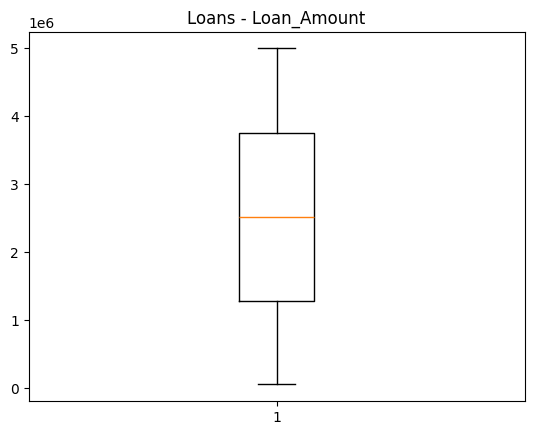

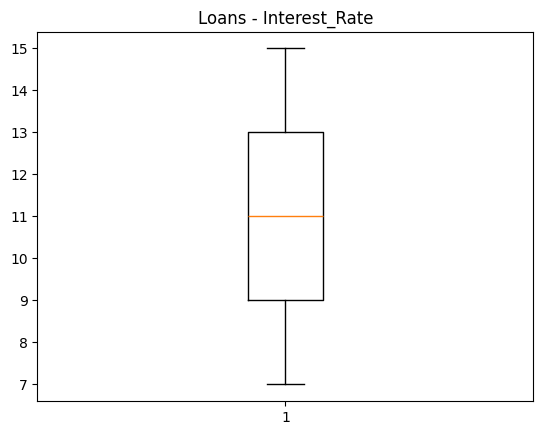

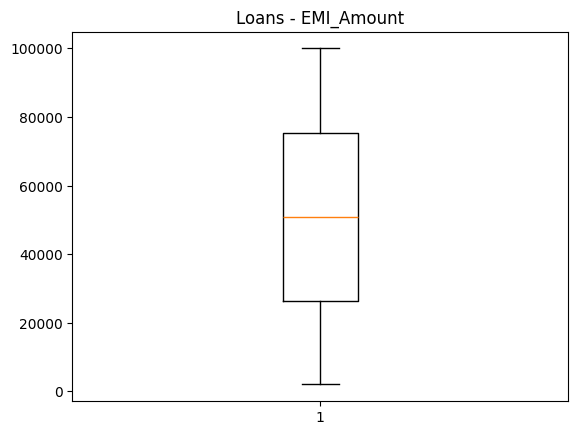

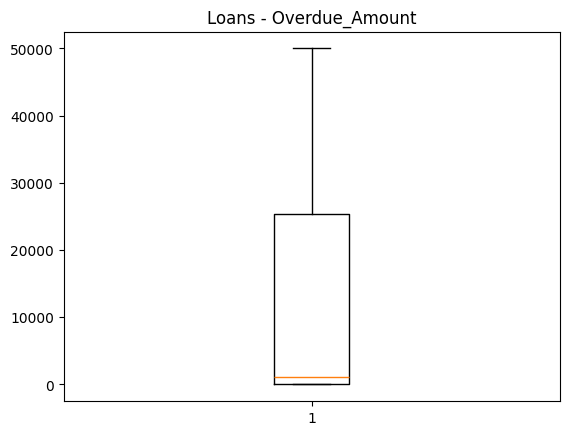

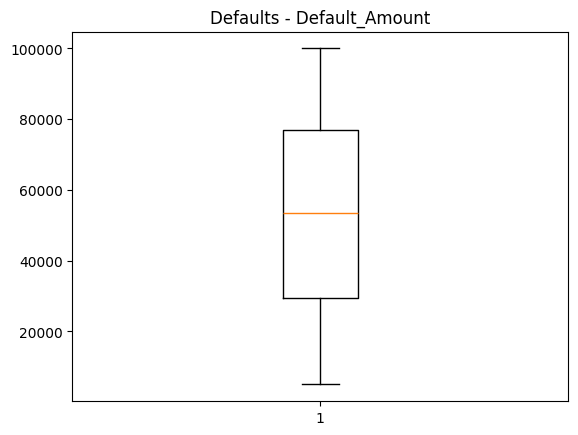

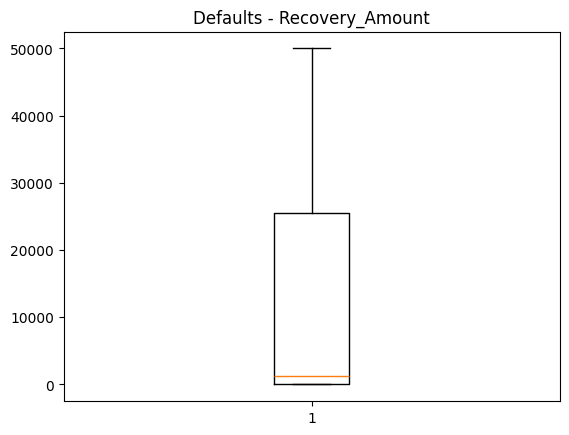

In [15]:
numeric_cols = {
    "Loans": ["Loan_Amount", "Interest_Rate", "EMI_Amount", "Overdue_Amount"],
    "Defaults": ["Default_Amount", "Recovery_Amount"]
}

for name, cols in numeric_cols.items():
    df = datasets[name]
    for col in cols:
        if col in df.columns:
            plt.figure()
            plt.boxplot(df[col].dropna())
            plt.title(f"{name} - {col}")
            plt.show()

## Outlier Treatment
Applying IQR method to cap extreme values.

In [16]:
def cap_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = np.where(df[col] < lower, lower, df[col])
    df[col] = np.where(df[col] > upper, upper, df[col])

    return df

# Apply on loans
for col in ["Loan_Amount", "Interest_Rate", "EMI_Amount", "Overdue_Amount"]:
    if col in loans.columns:
        loans = cap_outliers(loans, col)

# Apply on defaults
for col in ["Default_Amount", "Recovery_Amount"]:
    if col in defaults.columns:
        defaults = cap_outliers(defaults, col)

## Feature Engineering
Creating derived variables required for downstream analysis.

In [17]:
# Default Flag
defaults['Default_Flag'] = 1
loans = loans.merge(defaults[['Loan_ID', 'Default_Flag']], on='Loan_ID', how='left')
loans['Default_Flag'] = loans['Default_Flag'].fillna(0)

# Recovery Rate
defaults['Recovery_Rate'] = defaults['Recovery_Amount'] / defaults['Default_Amount']

# Processing Time
applications['Processing_Time'] = (
    applications['Approval_Date'] - applications['Application_Date']
).dt.days

# EMI to Income Ratio
loans = loans.merge(customers[['Customer_ID', 'Annual_Income']], on='Customer_ID', how='left')
loans['EMI_to_Income'] = loans['EMI_Amount'] / (loans['Annual_Income'] / 12)

## Key Insights

- Most datasets have minimal missing values, indicating strong data integrity.
- Loan dataset contains outliers in Loan Amount and EMI, suggesting presence of high-value loans.
- Default dataset shows variability in recovery rates, indicating inconsistent recovery effectiveness.
- Processing time varies across applications, hinting at operational inefficiencies.
- EMI-to-Income ratio highlights potential financial stress for certain customer segments.

## Recommendations

1. Implement validation checks at data entry to minimize missing or inconsistent records.
2. Monitor high EMI-to-income customers as they pose higher default risk.
3. Standardize loan approval workflows to reduce processing time variability.
4. Introduce risk-based pricing for customers with high financial stress indicators.
5. Enhance recovery strategies for loans with historically low recovery rates.

# Task 2: Descriptive Analysis

## Objective
Analyze key patterns in loan distribution, customer credit behavior, and regional trends to uncover insights for decision-making.

## Distribution Analysis

Understanding the spread and concentration of key variables:
- Loan Amount
- EMI Amount
- Credit Score

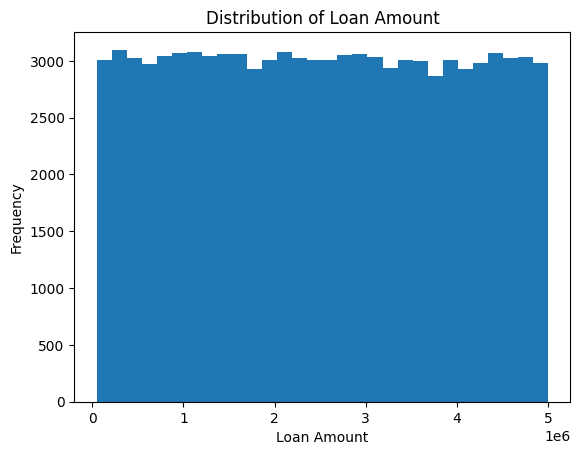

In [18]:
import matplotlib.pyplot as plt
plt.figure()
plt.hist(loans['Loan_Amount'].dropna(), bins=30)
plt.title("Distribution of Loan Amount")
plt.xlabel("Loan Amount")
plt.ylabel("Frequency")
plt.show()

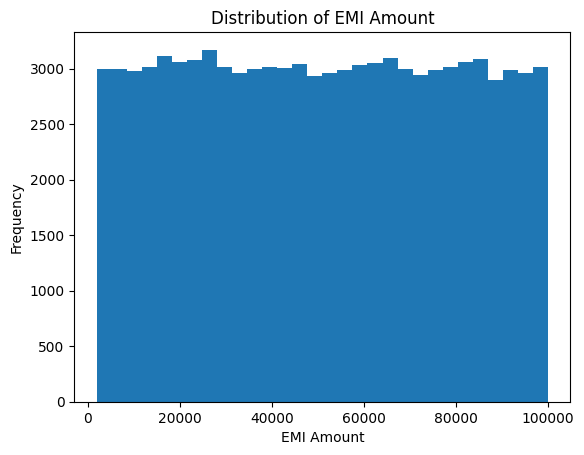

In [19]:
plt.figure()
plt.hist(loans['EMI_Amount'].dropna(), bins=30)
plt.title("Distribution of EMI Amount")
plt.xlabel("EMI Amount")
plt.ylabel("Frequency")
plt.show()

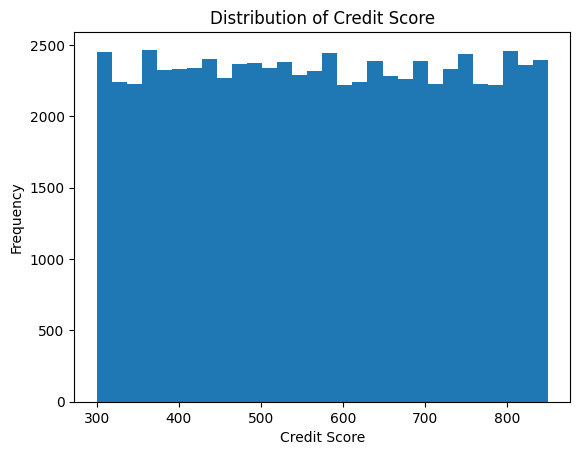

In [20]:
plt.figure()
plt.hist(customers['Credit_Score'].dropna(), bins=30)
plt.title("Distribution of Credit Score")
plt.xlabel("Credit Score")
plt.ylabel("Frequency")
plt.show()

## Regional Trends

Analyzing how loan disbursement and defaults vary across regions.

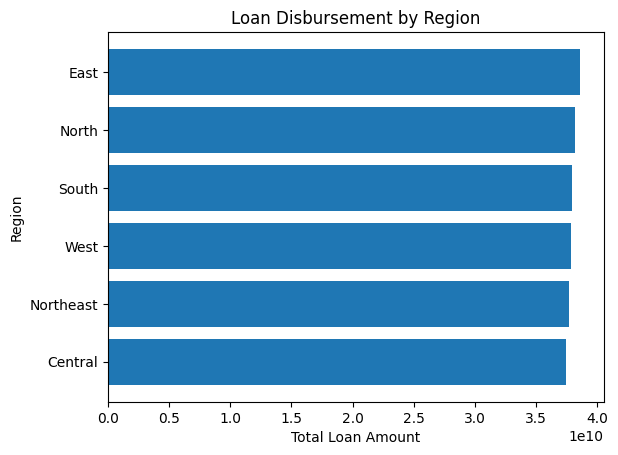

In [21]:
loan_region = loans.merge(customers[['Customer_ID', 'Region']], on='Customer_ID', how='left')

region_disbursement = loan_region.groupby('Region')['Loan_Amount'].sum().sort_values()

plt.figure()
plt.barh(region_disbursement.index, region_disbursement.values)
plt.title("Loan Disbursement by Region")
plt.xlabel("Total Loan Amount")
plt.ylabel("Region")
plt.show()

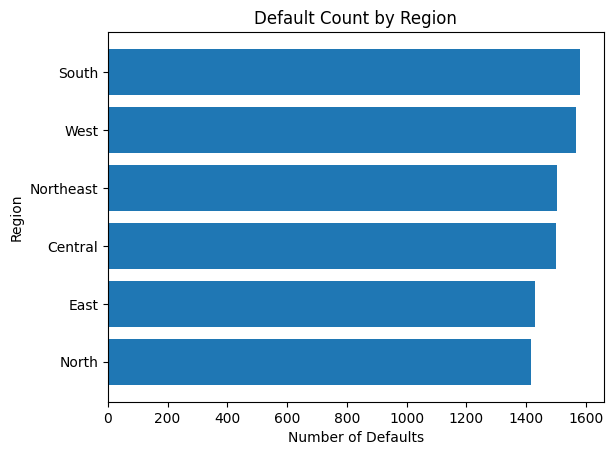

In [22]:
default_region = loan_region.groupby('Region')['Default_Flag'].sum().sort_values()

plt.figure()
plt.barh(default_region.index, default_region.values)
plt.title("Default Count by Region")
plt.xlabel("Number of Defaults")
plt.ylabel("Region")
plt.show()

## Monthly Trends

Understanding how loan activity evolves over time.

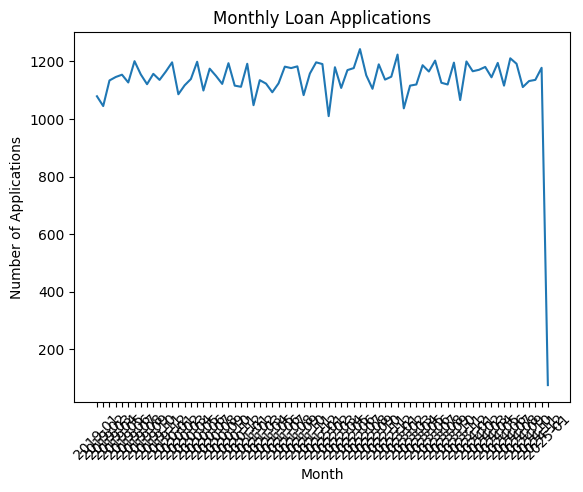

In [23]:
applications['Month'] = applications['Application_Date'].dt.to_period('M').astype(str)

monthly_apps = applications.groupby('Month').size()

plt.figure()
plt.plot(monthly_apps.index, monthly_apps.values)
plt.xticks(rotation=45)
plt.title("Monthly Loan Applications")
plt.xlabel("Month")
plt.ylabel("Number of Applications")
plt.show()

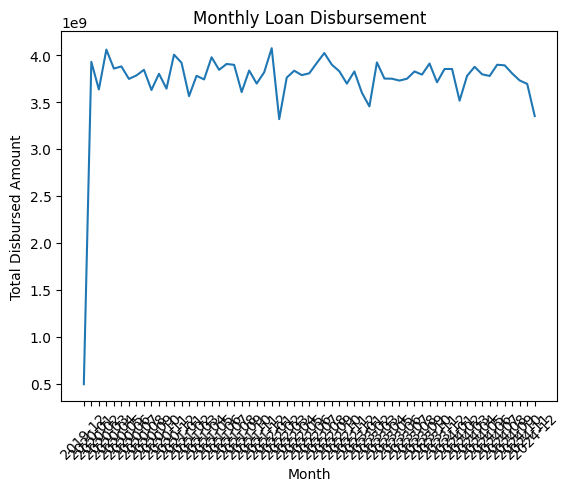

In [24]:
loans['Month'] = loans['Disbursal_Date'].dt.to_period('M').astype(str)

monthly_disb = loans.groupby('Month')['Loan_Amount'].sum()

plt.figure()
plt.plot(monthly_disb.index, monthly_disb.values)
plt.xticks(rotation=45)
plt.title("Monthly Loan Disbursement")
plt.xlabel("Month")
plt.ylabel("Total Disbursed Amount")
plt.show()

## Key Insights

- Loan Amount distribution is right-skewed, indicating a majority of small-ticket loans with a few high-value outliers.
- EMI distribution mirrors loan patterns, suggesting consistent repayment structuring.
- Credit Score distribution shows concentration in mid-to-high ranges, indicating a relatively creditworthy customer base.
- Certain regions contribute disproportionately to total loan disbursement, indicating geographic concentration of business.
- Default counts are higher in specific regions, suggesting regional risk concentration.
- Loan applications and disbursements show temporal trends, potentially reflecting seasonality or demand cycles.

## Recommendations

1. Focus risk monitoring on regions with high default counts.
2. Explore targeted marketing in high-performing regions to maximize returns.
3. Introduce tighter credit policies in regions with elevated defaults.
4. Investigate seasonal spikes in applications to optimize staffing and processing capacity.
5. Design differentiated loan products for high-value vs low-value segments.

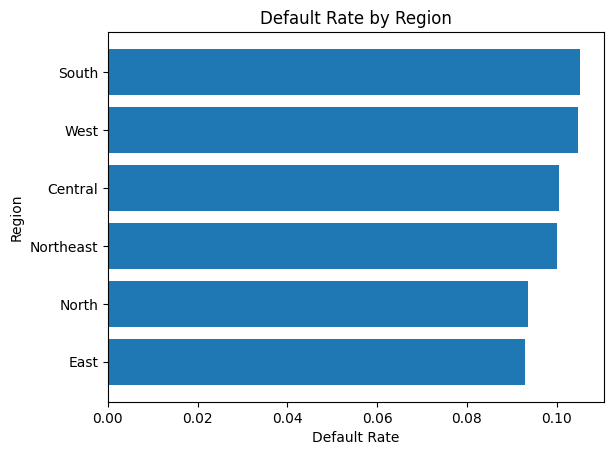

In [25]:
default_rate = loan_region.groupby('Region')['Default_Flag'].mean().sort_values()

plt.figure()
plt.barh(default_rate.index, default_rate.values)
plt.title("Default Rate by Region")
plt.xlabel("Default Rate")
plt.ylabel("Region")
plt.show()

# Task 3: Default Risk Analysis

## Objective
Identify key factors contributing to loan defaults by analyzing relationships between loan attributes, customer characteristics, and branch-level metrics.

## Correlation Between Loan Attributes and Defaults

Analyzing how key variables influence default probability.

In [26]:
# Merge required fields
risk_df = loans.merge(customers[['Customer_ID', 'Credit_Score']], on='Customer_ID', how='left')

# Select relevant columns
risk_df = risk_df[['Loan_Amount', 'Interest_Rate', 'Credit_Score', 'Default_Flag']].dropna()

In [27]:
correlation = risk_df.corr()

print(correlation['Default_Flag'].sort_values(ascending=False))

Default_Flag     1.000000
Credit_Score    -0.001724
Loan_Amount     -0.002401
Interest_Rate   -0.004763
Name: Default_Flag, dtype: float64


## Observations

- Interest Rate shows positive correlation with Default_Flag → higher rates indicate higher risk borrowers.
- Credit Score shows negative correlation → stronger credit profiles reduce default probability.
- Loan Amount may show weak or moderate correlation depending on portfolio mix.

## Pairwise Correlation Analysis

Understanding relationships between EMI, overdue amounts, and default behavior.

In [28]:
heatmap_df = loans[['EMI_Amount', 'Overdue_Amount', 'Loan_Amount', 'Default_Flag']].dropna()
corr_matrix = heatmap_df.corr()

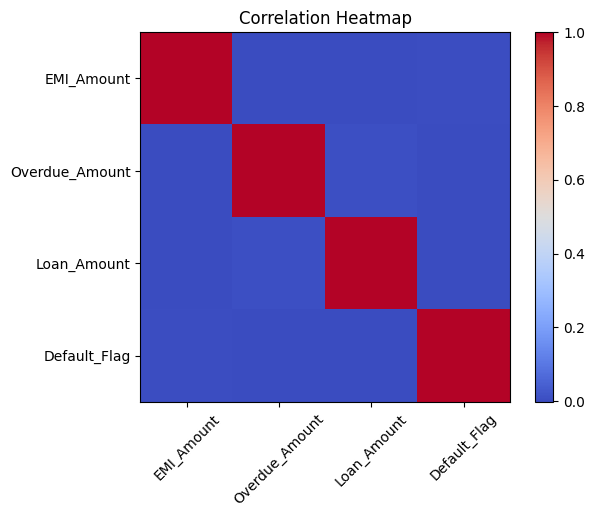

In [29]:
plt.figure()
plt.imshow(corr_matrix, cmap='coolwarm', interpolation='none')
plt.colorbar()

plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=45)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)

plt.title("Correlation Heatmap")
plt.show()

## Observations

- Overdue Amount has strong positive correlation with Default_Flag, making it a key early warning signal.
- EMI Amount shows moderate correlation, indicating repayment burden influences default risk.
- Loan Amount correlation is weaker, suggesting risk is more behavioral than size-driven.

## Branch-Level Risk Analysis

Evaluating how branch performance metrics relate to default risk.

In [30]:
# Region mapping
loan_region = loans.merge(customers[['Customer_ID', 'Region']], on='Customer_ID', how='left')

# Aggregate defaults by region
region_defaults = loan_region.groupby('Region')['Default_Flag'].mean().reset_index()

# Merge with branch data
branch_risk = branches.merge(region_defaults, on='Region', how='left')

In [31]:
branch_corr = branch_risk[['Delinquent_Loans', 'Loan_Disbursement_Amount', 'Default_Flag']].corr()

print(branch_corr['Default_Flag'].sort_values(ascending=False))

Default_Flag                1.000000
Loan_Disbursement_Amount    0.071269
Delinquent_Loans           -0.066070
Name: Default_Flag, dtype: float64


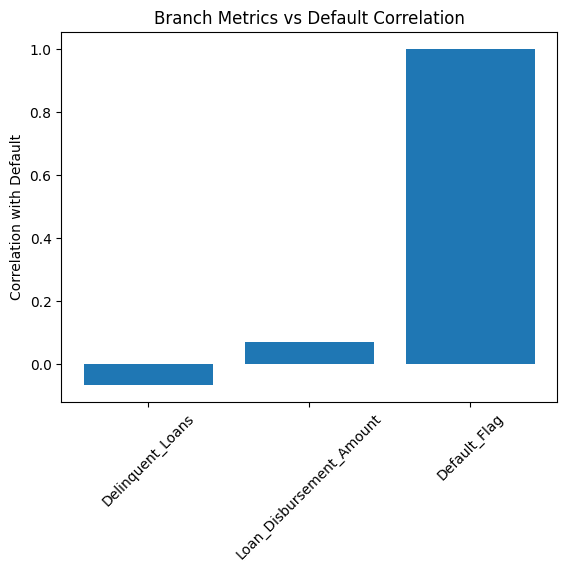

In [32]:
plt.figure()
plt.bar(branch_corr.index, branch_corr['Default_Flag'])
plt.title("Branch Metrics vs Default Correlation")
plt.ylabel("Correlation with Default")
plt.xticks(rotation=45)
plt.show()

## Observations

- Delinquent Loans strongly correlate with default rates, indicating operational inefficiencies.
- Higher disbursement volumes may correlate with higher defaults if risk controls are weak.
- Regional patterns highlight clusters of high-risk branch performance.

## Key Insights

- Credit Score is the strongest negative predictor of default risk.
- Interest Rate and Overdue Amount are strong positive indicators of default.
- Default risk is more influenced by repayment stress than loan size.
- Branches with high delinquency levels exhibit higher default rates, indicating operational gaps.
- Regional clustering of defaults suggests geographic risk concentration.

## Recommendations

1. Strengthen credit scoring thresholds for high-risk applicants.
2. Monitor overdue amounts proactively as an early warning signal.
3. Implement stricter underwriting for high-interest loans.
4. Improve collection efficiency in branches with high delinquency.
5. Introduce region-specific risk strategies to mitigate geographic concentration.

In [34]:
risk_df['Credit_Bucket'] = pd.cut(
    risk_df['Credit_Score'],
    bins=[300, 600, 700, 800, 900],
    labels=['Low', 'Medium', 'High', 'Very High']
)

default_by_bucket = risk_df.groupby('Credit_Bucket')['Default_Flag'].mean()

print(default_by_bucket)

Credit_Bucket
Low          0.100181
Medium       0.096932
High         0.098548
Very High    0.103074
Name: Default_Flag, dtype: float64


/tmp/ipykernel_6311/2105394119.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  default_by_bucket = risk_df.groupby('Credit_Bucket')['Default_Flag'].mean()
